In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import transformers
from transformers import TrainingArguments

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import matplotlib.pyplot as plt

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\Admin\AppData\Local\Programs\Python\Python310\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
df = pd.read_csv("news_dataset.csv")  
df.head()

,label,text
0,REAL,Payal has accused filmmaker Anurag Kashyap of ...
1,FAKE,A four-minute-long video of a woman criticisin...
2,FAKE,"Republic Poll, a fake Twitter account imitatin..."
3,REAL,"Delhi teen finds place on UN green list, turns..."
4,REAL,Delhi: A high-level meeting underway at reside...


In [3]:
print(df.shape)
print(df['label'].unique())

(3729, 2)
['REAL' 'FAKE']


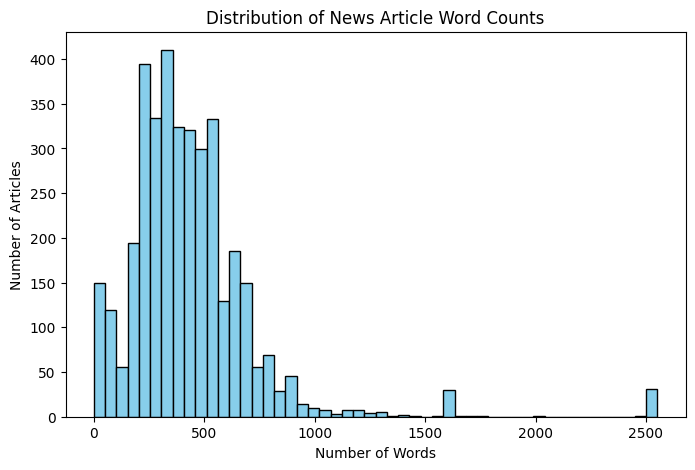

In [4]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of News Article Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.show()

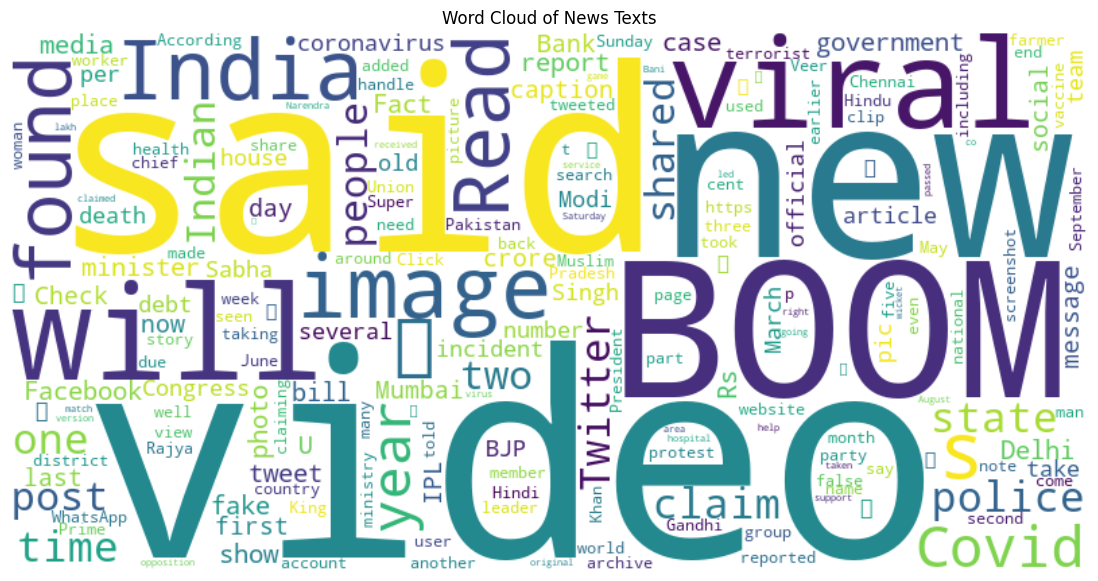

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_combined = " ".join(df['text'].astype(str).tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(text_combined)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud.to_image(), interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Texts")
plt.show()

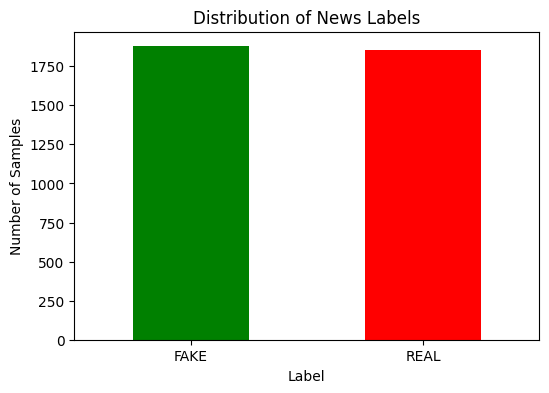

In [6]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['green', 'red'])
plt.title("Distribution of News Labels")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [7]:
label_map = {"FAKE": 0, "REAL": 1}
df['label'] = df['label'].map(label_map)

df = df.dropna(subset=['text', 'label'])

df['label'] = df['label'].astype(int)

print(df['label'].value_counts())

label
0    1871
1    1850
Name: count, dtype: int64


In [8]:
texts = df['text'].tolist()
labels = df['label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [9]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.config.problem_type = "single_label_classification"

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})

In [11]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/2976 [00:00<?, ? examples/s]

Map:   0%|          | 0/745 [00:00<?, ? examples/s]

In [12]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

training_args = TrainingArguments(
    output_dir="results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=50,
    load_best_model_at_end=True,
)

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    import numpy as np
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

In [14]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14440\3543899224.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.080900,0.011701,0.998658
2,0.002400,0.012911,0.998658
3,0.009400,0.013030,0.998658


C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1116, training_loss=0.03947595117833152, metrics={'train_runtime': 15255.3149, 'train_samples_per_second': 0.585, 'train_steps_per_second': 0.073, 'total_flos': 1174527751127040.0, 'train_loss': 0.03947595117833152, 'epoch': 3.0})

In [15]:
eval_results = trainer.evaluate()
print(eval_results)

model.save_pretrained("./english_fake_news_model")
tokenizer.save_pretrained("./english_fake_news_model")

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.011701368726789951, 'eval_accuracy': 0.9986577181208054, 'eval_runtime': 162.1156, 'eval_samples_per_second': 4.595, 'eval_steps_per_second': 0.58, 'epoch': 3.0}


('./english_fake_news_model\\tokenizer_config.json',
 './english_fake_news_model\\special_tokens_map.json',
 './english_fake_news_model\\vocab.txt',
 './english_fake_news_model\\added_tokens.json',
 './english_fake_news_model\\tokenizer.json')

In [41]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./english_fake_news_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

news_texts = ['''The video below contains distressing visuals. Viewer discretion is advised


''']

inputs = tokenizer(news_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).tolist()  

label_map = {1: "real", 0: "fake"}
predicted_labels = [label_map[p] for p in predictions]

for text, label in zip(news_texts, predicted_labels):
    print(f"News: {text}\nPrediction: {label}\n")

The tokenizer you are loading from './english_fake_news_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


News: The video below contains distressing visuals. Viewer discretion is advised



Prediction: fake

